# Import libraries

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import json
import os
from shapely.geometry import shape

In [2]:
oc_features_dir = "/sci-it/hosts/olympus/calgary/processed_data/open_calgary/20260327/features"
oc_metadata_dir = "/sci-it/hosts/olympus/calgary/processed_data/open_calgary/20260327/metadata"

## Utilities

In [3]:
def viz_gdf(_gdf):
    # Visualize the geometry objects using GeoPandas plotting
    _gdf.plot(column=None, edgecolor='black', figsize=(5, 3))
    plt.title("Geometry Visualization")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()
    return plt

In [50]:
def load_gdf(_file):
    return gpd.read_parquet(_file)
def load_json(_file):
    with open(_file, "r") as f:
        return json.load(f)

# Load desired metadata and parquet file(s)

## Open Calgary

In [46]:
# Load and preview parquet file in geopandas
file = "/sci-it/hosts/olympus/calgary/processed_data/open_calgary/20260327/features/point/uqkc-h9wi_SolarProductionSites_feature.parquet"

# Get feature columns
gdf = gpd.read_parquet(file)
gdf.head()

,:id,:version,:created_at,:updated_at,:@computed_region_4a3i_ccfj,:@computed_region_dspr_7vyd,:@computed_region_4b54_tmc4,facility_name,facility_address,rated_capacity,geometry
0,row-b4t5-5h2n.fccy,rv-szn9-8t3r~wgby,2025-10-21T21:28:31.278Z,2025-10-21T21:28:34.768Z,1,241,1,69 ST SW LRT PARKADE,7085 17 AV SW,30,POINT (-114.18925 51.03723)
1,row-8y7d.595z~buxy,rv-22ge-wvdq_ugwf,2025-10-21T21:28:31.278Z,2025-10-21T21:28:34.768Z,3,148,10,FIRE HEADQUARTERS,4144 11 ST SE,17,POINT (-114.0361 51.0175)
2,row-3upj~what-x9hn,rv-xn62_dde7_4aap,2025-10-21T21:28:31.278Z,2025-10-21T21:28:34.768Z,1,99,14,FIRE STATION 5,3129 14 ST SW,4.23,POINT (-114.09515 51.0264)
3,row-d7mc-ss65-2nqi,rv-5cwd_vt5w.p2y9,2025-10-21T21:28:31.278Z,2025-10-21T21:28:34.768Z,2,21,13,HASKAYNE LEGACY PARK PAVILION,9000 149 ST NW,33.6,POINT (-114.30371 51.13627)
4,row-fh54_4y4d~swag,rv-uh62_m72z~grgr,2025-10-21T21:28:31.278Z,2025-10-21T21:28:34.768Z,4,3,11,STONEY TRANSIT FACILITY,1921 128 AV NE,66.3,POINT (-114.01973 51.16669)


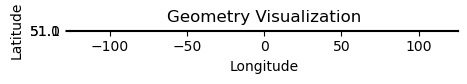

In [47]:
# Visualize the geometry objects using GeoPandas plotting
gdf.plot(column=None, edgecolor='black', figsize=(5, 3))
plt.title("Geometry Visualization")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## View Open Calgary that is not in Parquet file format

In [77]:
file = "/sci-it/hosts/olympus/calgary/processed_data/open_calgary/20260327/features/msye-bzwu_AnnualCorporateEnergyUseByBus_feature.json"

data = load_json(file)

# If data is a list of dicts, convert directly. Otherwise, adapt as needed.
df = pd.DataFrame(data)

df.head()

,:id,:version,:created_at,:updated_at,business_unit_desc,facilityname,site_id,facilityaddress,energy_description,year,month,total_consumption,unit,unique_id
0,row-n6uc.az6z_saph,rv-gaht_a2nt_v5u2,2026-03-04T20:42:32.310Z,2026-03-04T20:42:32.310Z,Calgary Fire Department,FIRE TRAINING FACILITY - ATCO VILLAGE SINGLE-F...,0020003498361,6015 23 AV SE,Electricity,2014,Jan,1883,kWh,0020003498361-6015 23 AV SE-Electricity-2014-Jan
1,row-jtgx~uxx6.9xbe,rv-ji3x_2skb~26es,2026-03-04T20:42:32.310Z,2026-03-04T20:42:32.310Z,Calgary Fire Department,FIRE TRAINING FACILITY - ATCO VILLAGE SINGLE-F...,0020003498361,6015 23 AV SE,Electricity,2014,Feb,2320,kWh,0020003498361-6015 23 AV SE-Electricity-2014-Feb
2,row-g67t~cieh_d4as,rv-thqb~u79y.carq,2026-03-04T20:42:32.310Z,2026-03-04T20:42:32.310Z,Calgary Fire Department,FIRE TRAINING FACILITY - ATCO VILLAGE SINGLE-F...,0020003498361,6015 23 AV SE,Electricity,2014,Mar,1657,kWh,0020003498361-6015 23 AV SE-Electricity-2014-Mar
3,row-miuj-ausw~uhby,rv-sbf7-sn6j~m2dm,2026-03-04T20:42:32.310Z,2026-03-04T20:42:32.310Z,Calgary Fire Department,FIRE TRAINING FACILITY - ATCO VILLAGE SINGLE-F...,0020003498361,6015 23 AV SE,Electricity,2014,Apr,1107,kWh,0020003498361-6015 23 AV SE-Electricity-2014-Apr
4,row-etsa.sj82_qq6f,rv-3jzi_6mce-mfc6,2026-03-04T20:42:32.310Z,2026-03-04T20:42:32.310Z,Calgary Fire Department,FIRE TRAINING FACILITY - ATCO VILLAGE SINGLE-F...,0020003498361,6015 23 AV SE,Electricity,2014,May,972,kWh,0020003498361-6015 23 AV SE-Electricity-2014-May


In [76]:
# Load and preview .json metadata file with pandas
file = "/sci-it/hosts/olympus/calgary/processed_data/open_calgary/20260327/metadata/k85e-i265_ResidentialSolarPhotovoltaicPvSystem_metadata.json"

with open(file, "r") as f:
    data = json.load(f)

keys_to_use = ["id", "name", "attribution", "createdAt", "description", "custom_fields", "metadata", "owner", "rights"]

for k in keys_to_use:
    try:
        print(k)
        print(data[k])
        print("--------------------------------")
    except:
        print(f"Error: {k} not found in metadata")
        pass


id
k85e-i265
--------------------------------
name
Residential Solar Photovoltaic (PV) System Potential
--------------------------------
attribution
The City of Calgary
--------------------------------
createdAt
1594749182
--------------------------------
description
This dataset demonstrates an optimal size of PV system to be installed on a rooftop area. It is an analysis of residential rooftops (excluding apartment complexes) to estimate a potential capacity of a PV installation. The analysis uses LiDAR data taken in 2022 to estimate solar irradiance and roof shape to estimate the number of 1m x 2m solar panels. This data is then used with PVWatts API created by NREL to estimate the annual AC generated per panel. Each address has one or more entries each representing a continuous area where panels could be installed.
--------------------------------
custom_fields
Error: custom_fields not found in metadata
metadata
{'custom_fields': {'License/Attribution': {'License URL': 'https://dat

## ENMAX

In [ ]:
gdf = load_gdf("/sci-it/hosts/olympus/calgary/processed_data/enmax/20260327/features/polygon/EnmaxDistributionLimit_features.parquet")
gdf.head()

In [ ]:
viz_gdf(gdf)

In [ ]:
# Load and preview .json metadata file with pandas
metadata = load_json("/sci-it/hosts/olympus/calgary/processed_data/enmax/20260327/metadata/EnmaxServiceArea_metadata.json")

keys_to_use = ["name", "description", "copyrightText", "editingInfo", "spatialReference"]

for k in keys_to_use:
    print(k)
    print(metadata[k])
    print("--------------------------------")


## Preview Open Calgary metadata from feature and metadata files

In [ ]:
# Print metadata keys of the corresponding metadata file in metadata_dir
for feature_file in os.listdir(oc_features_dir):
    # Expect corresponding metadata file with same base name but ending in _metadata.json
    if feature_file.endswith(".json"):
        base = feature_file.rsplit("_feature", 1)[0]
        metadata_file = f"{base}_metadata.json"

        metadata_path = os.path.join(oc_metadata_dir, metadata_file)
        feature_path = os.path.join(oc_features_dir, feature_file)

        with open(metadata_path, "r") as f:
            metadata = json.load(f)

        with open(feature_path, "r") as f:
            feature = json.load(f)

        print(f"~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
        print(f"\n--- {metadata_file} ---")
        print("Metadata keys:", list(metadata.keys()))
        print(f"\n--- {feature_file} ---")
        print("Feature keys:", list(feature[0].keys()))


## Preview metadata in all Open Calgary parquet files

In [ ]:
oc_parquet_dirs = [f"{oc_features_dir}/{d}" for d in os.listdir(oc_features_dir) if os.path.isdir(f"{oc_features_dir}/{d}")]

for parquet_dir in oc_parquet_dirs:
    for feature_file in os.listdir(parquet_dir):
        base = feature_file.rsplit("_feature", 1)[0]
        metadata_file = f"{base}_metadata.json"

        metadata_path = os.path.join(oc_metadata_dir, metadata_file)
        feature_path = os.path.join(parquet_dir, feature_file)
        
        with open(metadata_path, "r") as f:
            metadata = json.load(f)

        gdf = gpd.read_parquet(path)

        print(f"~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
        print(f"\n--- {metadata_file} ---")
        print("Metadata keys:", list(metadata.keys()))
        print(f"\n--- {feature_file} ---")
        print("Feature columns:", gdf.columns)



## Preview metadata in all ENMAX parquet files

In [ ]:
en_features_dir = "/sci-it/hosts/olympus/calgary/processed_data/enmax/20260327/features"
en_metadata_dir = "/sci-it/hosts/olympus/calgary/processed_data/enmax/20260327/metadata"
en_parquet_dirs = [f"{en_features_dir}/{d}" for d in os.listdir(en_features_dir) if os.path.isdir(f"{en_features_dir}/{d}")]

for parquet_dir in en_parquet_dirs:
    for feature_file in os.listdir(parquet_dir):
        base = feature_file.rsplit("_feature", 1)[0]
        metadata_file = f"{base}_metadata.json"
        metadata_path = os.path.join(en_metadata_dir, metadata_file)
        feature_path = os.path.join(parquet_dir, feature_file)
        try:
            # Get metadata
            with open(metadata_path, "r") as f:
                metadata = json.load(f)
            # Get feature columns
            gdf = gpd.read_parquet(feature_path)
            print(f"~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
            print(f"\n--- {metadata_file} ---")
            print("Metadata keys:", list(metadata.keys()))
            print(f"\n--- {feature_file} ---")
            print("Feature columns:", gdf.columns)
        except Exception as e:
            print(f"Failed to process {feature_file}: {e}")
